<a href="https://colab.research.google.com/github/SofiyaPatwekar/FishFreshAI/blob/main/NotebooksColab/06_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — ResNet50 (Transfer Learning)

Same two-phase pattern as `05_mobilenetv2.ipynb`: freeze the ImageNet
backbone and train the head, then unfreeze the top layers and fine-tune at
a much lower learning rate. Only the backbone, its `preprocess_input`, and
the unfreeze point change.

## Colab setup — run this first, every session

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, sys

DRIVE_PROJECT_PATH = "/content/drive/MyDrive/Fish_freshness_proj"  # <-- EDIT to your path

os.chdir(f"{DRIVE_PROJECT_PATH}/notebooks")
sys.path.append(os.getcwd())
print("Working directory:", os.getcwd())

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Fish_freshness_proj/notebooks


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt

from config import IMG_SIZE, MODELS_DIR
from pipeline_utils import get_datasets, get_class_weight

print(tf.config.list_physical_devices('GPU'))  # confirm GPU before training

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data — ResNet50's own `preprocess_input`

Different from MobileNetV2's: ResNet50's `preprocess_input` converts RGB to
BGR and zero-centers each channel using ImageNet means — it does NOT scale
to [-1, 1] or [0, 1]. Don't reuse either the baseline's `Rescaling(1/255)`
or MobileNetV2's preprocessing here; each backbone's `preprocess_input` is
specific to how it was originally trained.

In [ ]:
preprocess_input = tf.keras.applications.resnet50.preprocess_input

train_ds, val_ds, test_ds = get_datasets(normalize_fn=preprocess_input)
class_weight = get_class_weight()
print("class_weight:", class_weight)

Found 2810 files belonging to 2 classes.
Found 702 files belonging to 2 classes.
Found 878 files belonging to 2 classes.
class_weight: {0: 0.712113532691333, 1: 1.6786140979689366}


## Model

Same `training=False` reasoning as MobileNetV2 — keeps BatchNorm on its
pretrained running stats through both phases, including once some backbone
layers are unfrozen.

In [ ]:
base_model = tf.keras.applications.ResNet50(
    input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet"
)
base_model.trainable = False  # Phase A: fully frozen

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs, name="resnet50_transfer")
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Phase A — train the head only

Same reasoning as MobileNetV2: no `ModelCheckpoint` here, this phase just
warms up the head before unfreezing.

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

phase_a_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=5, restore_best_weights=True
    ),
]

history_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight,
    callbacks=phase_a_callbacks,
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 525s 3s/step - accuracy: 0.5566 - auc: 0.5725 - loss: 0.7934 - precision: 0.3500 - recall: 0.5699 - val_accuracy: 0.6111 - val_auc: 0.7074 - val_loss: 0.6577 - val_precision: 0.4119 - val_recall: 0.7308
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 35s 396ms/step - accuracy: 0.6260 - auc: 0.6864 - loss: 0.6577 - precision: 0.4171 - recall: 0.6428 - val_accuracy: 0.7151 - val_auc: 0.7486 - val_loss: 0.5611 - val_precision: 0.5163 - val_recall: 0.6106
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 399ms/step - accuracy: 0.6609 - auc: 0.7181 - loss: 0.6323 - precision: 0.4515 - recall: 0.6452 - val_accuracy: 0.6282 - val_auc: 0.7651 - val_loss: 0.6748 - val_precision: 0.4352 - val_recall: 0.8558
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 36s 399ms/step - accuracy: 0.6911 - auc: 0.7699 - loss: 0.5755 - precision: 0.4871 - recall: 0.6989 - val_accuracy: 0.7151 - val_auc: 0.7828 - val_loss: 0.5561 - val_precision: 0.5139 - val_recall: 0.7115
Epoch 5/10
88/88 ━━━━━━━━━━━━━

## Phase B — unfreeze the top layers, fine-tune

ResNet50 is deeper than MobileNetV2 (~175 layers here vs ~154), so "top 30"
is a smaller fraction of the network — still a reasonable starting point,
worth treating as tunable rather than fixed if results suggest otherwise.

In [ ]:
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30  # unfreeze only the top ~30 layers
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"Backbone layers: {len(base_model.layers)}, "
      f"trainable from index {FINE_TUNE_AT} onward")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc"),
    ],
)

checkpoint_path = MODELS_DIR / "resnet50_best.keras"
phase_b_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        str(checkpoint_path), monitor="val_auc", mode="max", save_best_only=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4, min_lr=1e-7
    ),
]

history_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=phase_b_callbacks,
)

Backbone layers: 175, trainable from index 145 onward
Epoch 1/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 77s 608ms/step - accuracy: 0.6986 - auc: 0.7912 - loss: 0.5548 - precision: 0.4960 - recall: 0.7360 - val_accuracy: 0.7593 - val_auc: 0.8069 - val_loss: 0.4950 - val_precision: 0.5867 - val_recall: 0.6346 - learning_rate: 1.0000e-05
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 39s 432ms/step - accuracy: 0.7498 - auc: 0.8334 - loss: 0.4997 - precision: 0.5600 - recall: 0.7467 - val_accuracy: 0.7479 - val_auc: 0.8176 - val_loss: 0.4887 - val_precision: 0.5628 - val_recall: 0.6683 - learning_rate: 1.0000e-05
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 43s 476ms/step - accuracy: 0.7950 - auc: 0.8774 - loss: 0.4378 - precision: 0.6228 - recall: 0.7909 - val_accuracy: 0.7650 - val_auc: 0.8309 - val_loss: 0.4644 - val_precision: 0.5982 - val_recall: 0.6298 - learning_rate: 1.0000e-05
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 44s 493ms/step - accuracy: 0.8075 - auc: 0.9031 - loss: 0.3968 - precision: 0.6343 - recall: 0.

## Verification

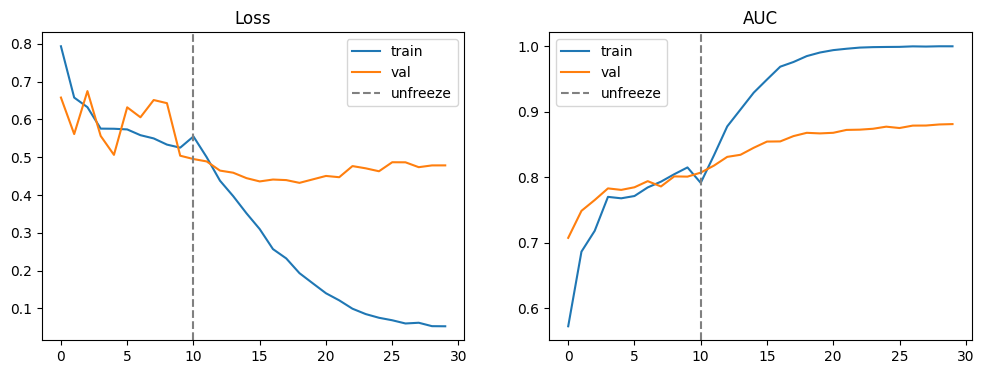

In [ ]:
def merge_histories(h1, h2):
    return {k: h1.history[k] + h2.history.get(k, []) for k in h1.history}

history = merge_histories(history_a, history_b)
phase_boundary = len(history_a.history["loss"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].axvline(phase_boundary, color="gray", linestyle="--", label="unfreeze")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["auc"], label="train")
axes[1].plot(history["val_auc"], label="val")
axes[1].axvline(phase_boundary, color="gray", linestyle="--", label="unfreeze")
axes[1].set_title("AUC"); axes[1].legend()
plt.show()

In [ ]:
print("Val metrics for the checkpointed model:")
model.evaluate(val_ds)

Val metrics for the checkpointed model:
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - accuracy: 0.8177 - auc: 0.8809 - loss: 0.4782 - precision: 0.6869 - recall: 0.7067


[0.47823166847229004,
 0.8176637887954712,
 0.6869158744812012,
 0.7067307829856873,
 0.8808976411819458]